In [1]:
using Plots, LaTeXStrings
pgfplotsx()

Plots.PGFPlotsXBackend()

In [2]:
ϕ(u,r) = 0.5*r*u^2-u^3/3+u^4/4 

ϕ (generic function with 1 method)

In [41]:
function add_tangent_arrows!(rvals, uvals; dir=:right, n_arrows=8, col=:magenta)

    idx = round.(Int, LinRange(10, length(rvals)-10, n_arrows))

    rx = rvals[idx]
    ux = uvals[idx]

    # numerical derivative du/dr
    du = similar(rx)
    dr = similar(rx)

    for (k,i) in enumerate(idx)
        dr[k] = rvals[i+1] - rvals[i-1]
        du[k] = uvals[i+1] - uvals[i-1]
    end

    # normalize direction
    norm = sqrt.(dr.^2 .+ du.^2)
    dr ./= norm
    du ./= norm

    scale = 0.05
    s = dir == :right ? 1 : -1

    quiver!(rx, ux,
            quiver=(s*scale*dr, s*scale*du),
            arrow=(:closed,7),
            color=col,
            lw=1.5)
end


add_tangent_arrows! (generic function with 1 method)

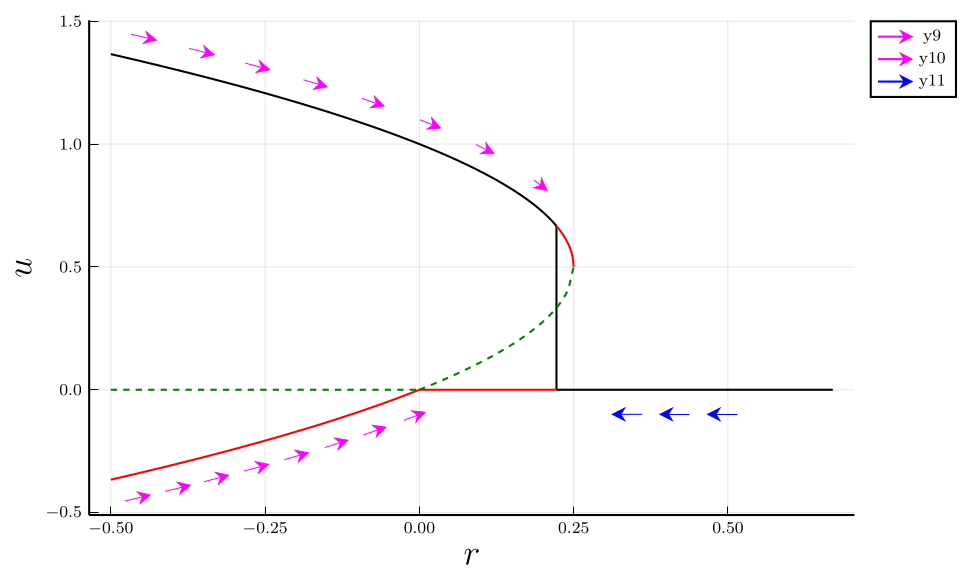

In [47]:
r1 = LinRange(-0.5,2/9,200)
r2 = LinRange(-0.5,0.0,200)
r3 = LinRange(2/9,0.67,30)
r4 = LinRange(2/9,0.25,30)
r5 = LinRange(0,2/9,30)
r6 = LinRange(0,0.25,30)
plot(r1, (@. 0.5 + sqrt(0.25 -r1)), c="black", label="")
plot!(r2, (@. 0.5 - sqrt(0.25 -r2)), c="red", label="")
plot!(r3, zeros(length(r3)), c="black", label="")
plot!([2/9, 2/9], [0,2/3],c="black", label="")
plot!(r4, (@. 0.5 + sqrt(0.25 -r4)), c="red", label="")
plot!(r5, zeros(length(r5)), c="red", label="")
plot!([-0.5,0],[0,0], ls=:dash, c="green", label="")
plot!(r6, (@. 0.5 - sqrt(0.25 -r6)), ls=:dash, c="green", label="")
xlabel!(L"r")
ylabel!(L"u")
plot!(guidefontsize=15, labelfontsize=18)
u_upper(r) = 0.5 + sqrt(0.25 - r)
u_lower(r) = 0.5 - sqrt(0.25 - r)

# Upper black branch (increasing r)
add_tangent_arrows!(r1, u_upper.(r1) .+0.1, dir=:right, col=:magenta)

# Lower red branch (increasing r)
add_tangent_arrows!(r2, u_lower.(r2) .-0.1, dir=:right, col=:magenta)

# Zero branch right side (decreasing r)
add_tangent_arrows!(r3, zeros(length(r3)) .- 0.1, dir=:left, col=:blue, n_arrows=3)
